In [3]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler


In [4]:
df = pd.read_csv("data2.csv")
print(df.head())

                                      Place_Name  Latitude  Longitude
0  Graphic Era Deemed to be University, Dehradun   30.2685    77.9968
1                                  ISBT Dehradun   30.2861    77.9954
2                         Clement Town, Dehradun   30.2662    78.0075
3                       Sahranpur Road, Dehradun   30.2988    77.9945
4                          Clock Tower, Dehradun   30.3244    78.0411


In [11]:
df


,Place_Name,Latitude,Longitude
0,"Graphic Era Deemed to be University, Dehradun",30.2685,77.9968
1,ISBT Dehradun,30.2861,77.9954
2,"Clement Town, Dehradun",30.2662,78.0075
3,"Sahranpur Road, Dehradun",30.2988,77.9945
4,"Clock Tower, Dehradun",30.3244,78.0411
...,...,...,...
2362,Bageshwar,29.8415,79.7712
2363,Kanjhawala Crossing,28.7211,NaN
2364,Kashipur,29.2104,78.9618
2365,NaN,25.0451,79.4451


In [12]:
df.shape

(2367, 3)

In [13]:
df.size

7101

In [14]:
df.columns

Index(['Place_Name', 'Latitude', 'Longitude'], dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2367 entries, 0 to 2366
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Place_Name  2244 non-null   object 
 1   Latitude    2254 non-null   float64
 2   Longitude   2259 non-null   float64
dtypes: float64(2), object(1)
memory usage: 55.6+ KB


In [16]:
df.describe()

,Latitude,Longitude
count,2254.000000,2259.000000
mean,27.691830,79.804069
std,3.091533,4.241633
min,20.701100,8.000000
25%,25.241100,77.201100
50%,28.583100,78.041100
75%,30.321100,82.631100
max,34.551100,95.351100


In [17]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 15


In [18]:
# Remove duplicates
df = df.drop_duplicates()
df


,Place_Name,Latitude,Longitude
0,"Graphic Era Deemed to be University, Dehradun",30.2685,77.9968
1,ISBT Dehradun,30.2861,77.9954
2,"Clement Town, Dehradun",30.2662,78.0075
3,"Sahranpur Road, Dehradun",30.2988,77.9945
4,"Clock Tower, Dehradun",30.3244,78.0411
...,...,...,...
2353,Kanhaiya Nagar,28.6811,77.1511
2358,Banjarawala,NaN,78.0311
2360,NaN,26.9911,75.7611
2363,Kanjhawala Crossing,28.7211,NaN


In [19]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [20]:
print(df.isnull().sum())

Place_Name    120
Latitude      113
Longitude     108
dtype: int64


In [21]:
# Remove null values
df = df.dropna()

In [22]:
print(df.isnull().sum())

Place_Name    0
Latitude      0
Longitude     0
dtype: int64


In [23]:
df.loc[:, "Place_Name"] = df["Place_Name"].fillna("UNKNOWN")
df

,Place_Name,Latitude,Longitude
0,"Graphic Era Deemed to be University, Dehradun",30.2685,77.9968
1,ISBT Dehradun,30.2861,77.9954
2,"Clement Town, Dehradun",30.2662,78.0075
3,"Sahranpur Road, Dehradun",30.2988,77.9945
4,"Clock Tower, Dehradun",30.3244,78.0411
...,...,...,...
2343,Bandgaon Crossing,22.8811,85.3811
2344,Chakradharpur RS North,22.7011,85.6211
2345,Chaibasa Bypass North,22.5611,85.8111
2346,Jhinkpani RS North,22.4111,8.0000


In [24]:
df.loc[:, "Latitude"] = df["Latitude"].fillna(df["Latitude"].mean())
df.loc[:, "Longitude"] = df["Longitude"].fillna(df["Longitude"].mean())
df

,Place_Name,Latitude,Longitude
0,"Graphic Era Deemed to be University, Dehradun",30.2685,77.9968
1,ISBT Dehradun,30.2861,77.9954
2,"Clement Town, Dehradun",30.2662,78.0075
3,"Sahranpur Road, Dehradun",30.2988,77.9945
4,"Clock Tower, Dehradun",30.3244,78.0411
...,...,...,...
2343,Bandgaon Crossing,22.8811,85.3811
2344,Chakradharpur RS North,22.7011,85.6211
2345,Chaibasa Bypass North,22.5611,85.8111
2346,Jhinkpani RS North,22.4111,8.0000


In [25]:
df.shape

(2030, 3)

In [26]:
# valid coordinate
df = df[(df['Latitude'].between(-90, 90)) & (df['Longitude'].between(-180, 180))]

In [27]:
df['Latitude'] = df['Latitude'].astype(float)
df['Longitude'] = df['Longitude'].astype(float)
df

,Place_Name,Latitude,Longitude
0,"Graphic Era Deemed to be University, Dehradun",30.2685,77.9968
1,ISBT Dehradun,30.2861,77.9954
2,"Clement Town, Dehradun",30.2662,78.0075
3,"Sahranpur Road, Dehradun",30.2988,77.9945
4,"Clock Tower, Dehradun",30.3244,78.0411
...,...,...,...
2343,Bandgaon Crossing,22.8811,85.3811
2344,Chakradharpur RS North,22.7011,85.6211
2345,Chaibasa Bypass North,22.5611,85.8111
2346,Jhinkpani RS North,22.4111,8.0000


In [28]:
df["Place_Name"] = df["Place_Name"].str.upper().str.strip()

In [29]:
z1 = (df["Latitude"] - df["Latitude"].mean()) / df["Latitude"].std()
z2 = (df["Longitude"] - df["Longitude"].mean()) / df["Longitude"].std()
df = df[(np.abs(z1) <= 3) & (np.abs(z2) <= 3)]
df

,Place_Name,Latitude,Longitude
0,"GRAPHIC ERA DEEMED TO BE UNIVERSITY, DEHRADUN",30.2685,77.9968
1,ISBT DEHRADUN,30.2861,77.9954
2,"CLEMENT TOWN, DEHRADUN",30.2662,78.0075
3,"SAHRANPUR ROAD, DEHRADUN",30.2988,77.9945
4,"CLOCK TOWER, DEHRADUN",30.3244,78.0411
...,...,...,...
2342,KHUNTI MARKET NORTH,23.0711,85.2811
2343,BANDGAON CROSSING,22.8811,85.3811
2344,CHAKRADHARPUR RS NORTH,22.7011,85.6211
2345,CHAIBASA BYPASS NORTH,22.5611,85.8111


In [30]:
df.shape

(2019, 3)

In [31]:
Q1_lat = df["Latitude"].quantile(0.25)
Q3_lat = df["Latitude"].quantile(0.75)
IQR_lat = Q3_lat - Q1_lat
df = df[(df["Latitude"] >= Q1_lat - 1.5*IQR_lat) &
(df["Latitude"] <= Q3_lat + 1.5*IQR_lat)]
df


,Place_Name,Latitude,Longitude
0,"GRAPHIC ERA DEEMED TO BE UNIVERSITY, DEHRADUN",30.2685,77.9968
1,ISBT DEHRADUN,30.2861,77.9954
2,"CLEMENT TOWN, DEHRADUN",30.2662,78.0075
3,"SAHRANPUR ROAD, DEHRADUN",30.2988,77.9945
4,"CLOCK TOWER, DEHRADUN",30.3244,78.0411
...,...,...,...
2342,KHUNTI MARKET NORTH,23.0711,85.2811
2343,BANDGAON CROSSING,22.8811,85.3811
2344,CHAKRADHARPUR RS NORTH,22.7011,85.6211
2345,CHAIBASA BYPASS NORTH,22.5611,85.8111


In [32]:
# Min-Max Scaling
minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[["Latitude", "Longitude"]] = minmax.fit_transform(df[["Latitude", "Longitude"]])
df_minmax

,Place_Name,Latitude,Longitude
0,"GRAPHIC ERA DEEMED TO BE UNIVERSITY, DEHRADUN",0.690787,0.235867
1,ISBT DEHRADUN,0.692058,0.235790
2,"CLEMENT TOWN, DEHRADUN",0.690621,0.236456
3,"SAHRANPUR ROAD, DEHRADUN",0.692975,0.235740
4,"CLOCK TOWER, DEHRADUN",0.694823,0.238305
...,...,...,...
2342,KHUNTI MARKET NORTH,0.171119,0.636764
2343,BANDGAON CROSSING,0.157401,0.642267
2344,CHAKRADHARPUR RS NORTH,0.144404,0.655476
2345,CHAIBASA BYPASS NORTH,0.134296,0.665933


In [33]:
# Standard Scaling
std = StandardScaler()
df_standard = df.copy()
df_standard[["Latitude", "Longitude"]] = std.fit_transform(df[["Latitude", "Longitude"]])
df_standard

,Place_Name,Latitude,Longitude
0,"GRAPHIC ERA DEEMED TO BE UNIVERSITY, DEHRADUN",0.828070,-0.462064
1,ISBT DEHRADUN,0.833752,-0.462425
2,"CLEMENT TOWN, DEHRADUN",0.827327,-0.459303
3,"SAHRANPUR ROAD, DEHRADUN",0.837852,-0.462657
4,"CLOCK TOWER, DEHRADUN",0.846118,-0.450633
...,...,...,...
2342,KHUNTI MARKET NORTH,-1.495647,1.417487
2343,BANDGAON CROSSING,-1.556990,1.443290
2344,CHAKRADHARPUR RS NORTH,-1.615104,1.505217
2345,CHAIBASA BYPASS NORTH,-1.660304,1.554242


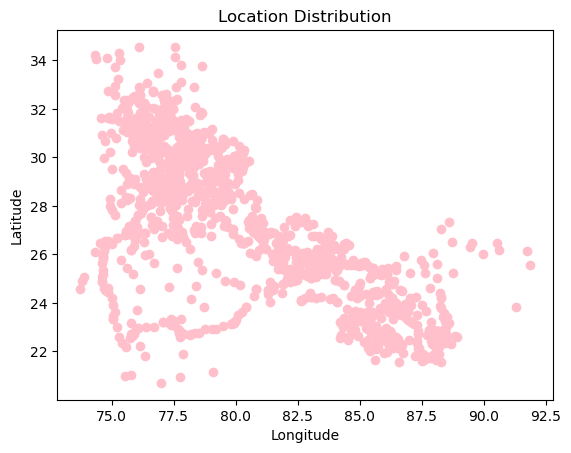

In [34]:
plt.scatter(df["Longitude"], df["Latitude"],color="pink")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Location Distribution")
plt.show()

In [35]:
df.shape

(2019, 3)

In [36]:
df.size

6057

In [37]:
corr = df[["Latitude", "Longitude"]].corr()
print(corr)

           Latitude  Longitude
Latitude   1.000000  -0.693517
Longitude -0.693517   1.000000


In [38]:
df = df.copy()
df = df.dropna(subset=["Place_Name", "Latitude", "Longitude"])
df = df.reset_index(drop=True)

In [39]:
coords = dict(zip(df["Place_Name"], zip(df["Latitude"], df["Longitude"])))


In [41]:

# Step 1: Build graph
graph = {}

for i in range(len(df)):
    city1 = df.loc[i, "Place_Name"]
    lat1 = df.loc[i, "Latitude"]
    lon1 = df.loc[i, "Longitude"]

    distances = []

    for j in range(len(df)):
        if i == j:
            continue

        city2 = df.loc[j, "Place_Name"]
        lat2 = df.loc[j, "Latitude"]
        lon2 = df.loc[j, "Longitude"]

        dist = ((lat2 - lat1)**2 + (lon2 - lon1)**2)**0.5
        distances.append((city2, dist))

    distances.sort(key=lambda x: x[1])
    graph[city1] = [city for city, _ in distances[:3]]


for city in graph:
    for neighbor in graph[city]:
        if city not in graph[neighbor]:
            graph[neighbor].append(city)

In [42]:
print(list(graph.keys())[:20])


['GRAPHIC ERA DEEMED TO BE UNIVERSITY, DEHRADUN', 'ISBT DEHRADUN', 'CLEMENT TOWN, DEHRADUN', 'SAHRANPUR ROAD, DEHRADUN', 'CLOCK TOWER, DEHRADUN', 'RAJPUR ROAD, DEHRADUN', 'BALLUPUR CHOWK, DEHRADUN', 'PREM NAGAR, DEHRADUN', 'MUSSOORIE LIBRARY CHOWK', 'LAL TIBBA, MUSSOORIE', 'SELAKUI INDUSTRIAL AREA', 'HERBERTPUR', 'PAONTA SAHIB', 'CHHUTMALPUR', 'SAHARANPUR JUNCTION', 'ROORKEE IIT CAMPUS', 'ROORKEE CIVIL LINES', 'HARIDWAR HAR KI PAURI', 'PATANJALI YOGPEETH, HARIDWAR', 'RISHIKESH LAXMAN JHULA']


In [43]:
print("Total cities:", len(graph))
print("Sample:", list(graph.items())[:3])

Total cities: 2019
Sample: [('GRAPHIC ERA DEEMED TO BE UNIVERSITY, DEHRADUN', ['SUBHASH NAGAR, DEHRADUN', 'SMITH NAGAR', 'SUBHASH NAGAR MARKET', 'TURNER ROAD', 'GRAPHIC ERA HOSPITAL']), ('ISBT DEHRADUN', ['LALPUL DEHRADUN', 'SAHRANPUR ROAD, DEHRADUN', 'MAJRA, DEHRADUN']), ('CLEMENT TOWN, DEHRADUN', ['KANDOLI', 'SOCIETY AREA CLEMENT TWN', 'SGRR CLEMENT TOWN', 'MINDROLLING MONASTERY', 'CLEMENT TOWN MARKET', 'LAKSHYA CLASSES CLEMENT'])]


In [44]:

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km

    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    c = 2 * math.asin(math.sqrt(a))

    return R * c

In [45]:
def heuristic(lat1, lon1, lat2, lon2):
    return ((lat2 - lat1)**2 + (lon2 - lon1)**2)**0.5 * 111

In [46]:
import heapq

def astar(graph, start, goal, coords):
    open_list = []
    heapq.heappush(open_list, (0, start))

    g_cost = {node: float('inf') for node in graph}
    g_cost[start] = 0

    parent = {}

    while open_list:
        _, current = heapq.heappop(open_list)

        # Goal reached
        if current == goal:
            path = []
            while current in parent:
                path.append(current)
                current = parent[current]
            path.append(start)
            return path[::-1], g_cost[goal]

        for neighbor in graph[current]:
            lat1, lon1 = coords[current]
            lat2, lon2 = coords[neighbor]

            # g(n)
            cost = g_cost[current] + haversine(lat1, lon1, lat2, lon2)

            if cost < g_cost[neighbor]:
                g_cost[neighbor] = cost

                # h(n)
                latg, longg = coords[goal]
                h = heuristic(lat2, lon2, latg, longg)

                # f(n)
                f = cost + h

                heapq.heappush(open_list, (f, neighbor))
                parent[neighbor] = current

    return None, float('inf')

In [47]:
start = input("Enter start city: ").strip().upper()
goal = input("Enter goal city: ").strip().upper()

if start not in graph or goal not in graph:
    print("Invalid city name!")
else:
    path, distance = astar(graph, start, goal, coords)

    print("Shortest Path:", " → ".join(path))
    print("Total Distance:", round(distance, 2), "km")

Enter start city:  SGRR CLEMENT TOWN
Enter goal city:  RISHIKESH LAXMAN JHULA


Shortest Path: SGRR CLEMENT TOWN → KANDOLI → BHARUWALA → BANJARAWALA → SARSARI → INDRESH HOSPITAL → GMS ROAD → KANWALI → VIKAS BHAWAN DEHRADUN → CHAKARATA ROAD CROSSING → BALLUPUR CHOWK, DEHRADUN → ONGC HOSPITAL DEHRADUN → MOHIT NAGAR DEHRADUN → PUNDIR ENCLAVE → PREM NAGAR, DEHRADUN → NANDA KI CHOWKI → TULAS INSTITUTE DEHRADUN → JHAJRA → CENTRAL HOPE TOWN → SELAKUI INDUSTRIAL AREA → SAKATPUR DEHRADUN → SAHASPUR MARKET → LANGHA ROAD CROSSING → PACHWA DOON CROSSING → PAONTA SAHIB → KHIZRABAD → BEHAT → SHAHJAHANPUR PARK → CHHUTMALPUR → DHANAURI → COER ROORKEE → GANGNAHAR, ROORKEE → MANGLAUR → LAKSAR → BAHADRABAD → JWALAPUR → MAYA DEVI TEMPLE → MOTICHUR STATION → KHANDRAUNKHI → SATYANARAYAN TEMPLE → MOTICHUR RANGE → CHIDDERWALA → GUMANIWALA → IDPL RISHIKESH → TRIVENI GHAT, RISHIKESH → RISHIKESH LAXMAN JHULA
Total Distance: 224.07 km


In [48]:
path, distance = astar(graph, start, goal, coords)

# Fix nested issue (safety)
path = [p if isinstance(p, str) else p[0] for p in path]

print("Shortest Path:", " → ".join(path))
print("Total Distance:", round(distance, 2), "km")

Shortest Path: SGRR CLEMENT TOWN → KANDOLI → BHARUWALA → BANJARAWALA → SARSARI → INDRESH HOSPITAL → GMS ROAD → KANWALI → VIKAS BHAWAN DEHRADUN → CHAKARATA ROAD CROSSING → BALLUPUR CHOWK, DEHRADUN → ONGC HOSPITAL DEHRADUN → MOHIT NAGAR DEHRADUN → PUNDIR ENCLAVE → PREM NAGAR, DEHRADUN → NANDA KI CHOWKI → TULAS INSTITUTE DEHRADUN → JHAJRA → CENTRAL HOPE TOWN → SELAKUI INDUSTRIAL AREA → SAKATPUR DEHRADUN → SAHASPUR MARKET → LANGHA ROAD CROSSING → PACHWA DOON CROSSING → PAONTA SAHIB → KHIZRABAD → BEHAT → SHAHJAHANPUR PARK → CHHUTMALPUR → DHANAURI → COER ROORKEE → GANGNAHAR, ROORKEE → MANGLAUR → LAKSAR → BAHADRABAD → JWALAPUR → MAYA DEVI TEMPLE → MOTICHUR STATION → KHANDRAUNKHI → SATYANARAYAN TEMPLE → MOTICHUR RANGE → CHIDDERWALA → GUMANIWALA → IDPL RISHIKESH → TRIVENI GHAT, RISHIKESH → RISHIKESH LAXMAN JHULA
Total Distance: 224.07 km


In [ ]:
features = []
for i in range(len(df)):
    for j in range(len(df)):
        if i == j:
            continue
        
        lat1, lon1 = df.loc[i, ["Latitude", "Longitude"]]
        lat2, lon2 = df.loc[j, ["Latitude", "Longitude"]]
        
        dist = math.sqrt((lat1 - lat2)**2 + (lon1 - lon2)**2)
        
        # Derived features
        traffic = np.random.uniform(0, 1)
        road_quality = np.random.uniform(0, 1)
        
        # Label (classification target)
        label = 1 if (traffic < 0.5 and road_quality > 0.5) else 0
        
        features.append([dist, traffic, road_quality, label])

clf_df = pd.DataFrame(features, columns=["distance", "traffic", "road_quality", "label"])

In [ ]:
from sklearn.linear_model import LogisticRegression

X = clf_df[["distance", "traffic", "road_quality"]]
y = clf_df["label"]

model = LogisticRegression()
model.fit(X, y)

In [ ]:
print("Slope (coefficient):", model.coef_)
print("Intercept:", model.intercept_)

In [ ]:
print("R² Score:", model.score(X, y))

In [ ]:
y_pred = model.predict(X)

In [ ]:
print(model.coef_)
print(model.score(X, y))